#### This notebook is created to check the data is pulled properly from yfinance

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [27]:
connection = sqlite3.connect("../data/data.db")

#### Reading the whole database

In [28]:
df = pd.read_sql("SELECT * FROM stocks", connection)

In [29]:
df

,stockId,companyName,date,open,high,low,close,volume
0,5011,AAPL,2024-02-23,183.341435,183.371163,180.586508,180.873901,45119700
1,5012,AAPL,2024-02-26,180.596415,181.111714,179.020743,179.526154,40867400
2,5013,AAPL,2024-02-27,179.466695,182.261254,177.940575,180.982895,54318900
3,5014,AAPL,2024-02-28,180.863995,181.468494,178.505469,179.783829,48953900
4,5015,AAPL,2024-02-29,179.635172,180.923451,177.910859,179.119858,136682600
...,...,...,...,...,...,...,...,...
2500,7511,META,2026-02-17,639.500000,642.599976,628.799988,639.289978,12674700
2501,7512,META,2026-02-18,633.799988,645.000000,628.150024,643.219971,14649200
2502,7513,META,2026-02-19,638.570007,647.190002,636.719971,644.780029,10035700
2503,7514,META,2026-02-20,639.690002,663.349976,638.780029,655.659973,14166900


In [30]:
df["companyName"].unique()

<StringArray>
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']
Length: 5, dtype: str

In [31]:
AAPL_df = df[df["companyName"] == "AAPL"]

In [32]:
AAPL_df

,stockId,companyName,date,open,high,low,close,volume
0,5011,AAPL,2024-02-23,183.341435,183.371163,180.586508,180.873901,45119700
1,5012,AAPL,2024-02-26,180.596415,181.111714,179.020743,179.526154,40867400
2,5013,AAPL,2024-02-27,179.466695,182.261254,177.940575,180.982895,54318900
3,5014,AAPL,2024-02-28,180.863995,181.468494,178.505469,179.783829,48953900
4,5015,AAPL,2024-02-29,179.635172,180.923451,177.910859,179.119858,136682600
...,...,...,...,...,...,...,...,...
496,5507,AAPL,2026-02-17,258.049988,266.290009,255.539993,263.880005,58469100
497,5508,AAPL,2026-02-18,263.600006,266.820007,262.450012,264.350006,34203300
498,5509,AAPL,2026-02-19,262.600006,264.480011,260.049988,260.579987,30845300
499,5510,AAPL,2026-02-20,258.970001,264.750000,258.160004,264.579987,42044900


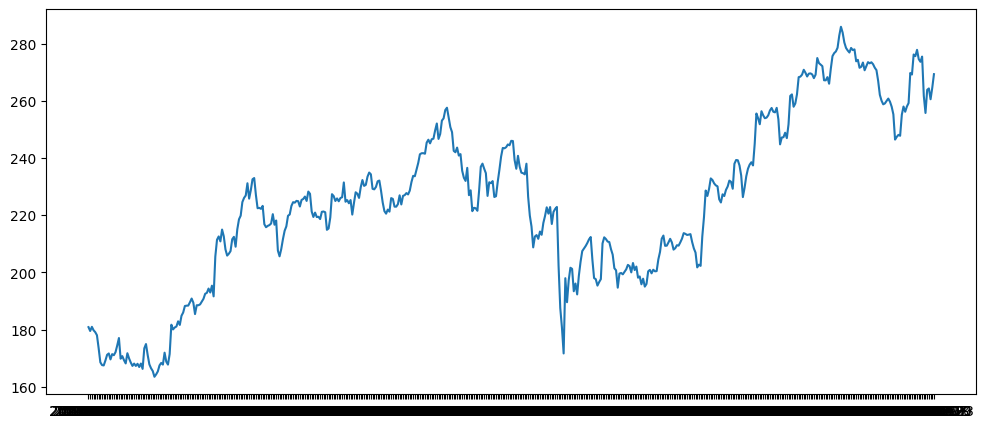

In [33]:
plt.figure(figsize=(12,5))
plt.plot(AAPL_df.date, AAPL_df["close"])
plt.show()

In [34]:
df = pd.read_sql("SELECT COUNT(*) as total FROM stocks", connection)
df

,total
0,2505


In [38]:
connection.execute("DELETE FROM stocks WHERE companyName = 'AAPL'")
connection.commit()

In [39]:
pd.read_sql("SELECT DISTINCT companyName FROM stocks", connection)

,companyName
0,AMZN
1,GOOGL
2,META
3,MSFT


In [40]:
df = pd.read_sql("SELECT COUNT(*) as total FROM stocks", connection)
df

,total
0,2004


I think the deletion and proper updation is working